# **1. Problem Statement**
## **You are a Data Analyst hired at a company. Your manager has given you a real-world dataset and asked you to understand the data, find patterns and trends, visualize the key insights, and write a clear report with 5 business or research recommendations based on your findings.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## **STEP - 1: Load and Inspect the Data**

In [ ]:
df = pd.read_csv('/content/Zomato_Data.csv', encoding='latin1')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   CountryName           9551 non-null   object 
 4   City                  9551 non-null   object 
 5   Address               9551 non-null   object 
 6   Locality              9551 non-null   object 
 7   Locality Verbose      9551 non-null   object 
 8   Longitude             9551 non-null   float64
 9   Latitude              9551 non-null   float64
 10  Cuisines              9542 non-null   object 
 11  Average Cost for two  9551 non-null   int64  
 12  Currency              9551 non-null   object 
 13  Has Table booking     9551 non-null   object 
 14  Has Online delivery   9551 non-null   object 
 15  Is delivering now    

### **Check Shape**

In [ ]:
df.shape

(9551, 22)

**Observation:** The dataset contains 9551 rows and 21 columns.

### **Check Data Types**

In [ ]:
df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
CountryName,object
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64


### **Observation :**
1. The Zomato dataset contains information about restaurants, including their names, locations, cuisines, ratings, costs, and delivery services.
2. The dataset consists of multiple numerical and categorical features that can be used for restaurant market analysis.
3. Missing values are present in some columns and handled during the data cleaning phase.
4. The dataset includes restaurants from multiple countries, allowing country-wise and city-wise analysis.
5. The data can be used to identify trends in restaurant ratings, customer preferences, pricing, and online delivery services.


## **Step 2 - Clean the Data**

### **Check Duplicate Values**

In [ ]:
df.duplicated().sum()

np.int64(0)

### **Check Null Values**

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
CountryName,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0


### **Handling Null Values**

In [ ]:
df = df.dropna(subset=['Cuisines'])
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
CountryName             0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


### **Check Column Names**

In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'CountryName',
       'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude',
       'Latitude', 'Cuisines', 'Average Cost for two', 'Currency',
       'Has Table booking', 'Has Online delivery', 'Is delivering now',
       'Switch to order menu', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes'],
      dtype='object')

### **Removing Irrelevant Columns**

In [ ]:
cols_to_drop = [
    'Restaurant ID',
    'Address',
    'Locality Verbose'
]

df.drop(columns=cols_to_drop, inplace=True)

In [ ]:
df.columns

Index(['Restaurant Name', 'Country Code', 'CountryName', 'City', 'Locality',
       'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency',
       'Has Table booking', 'Has Online delivery', 'Is delivering now',
       'Switch to order menu', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes'],
      dtype='object')

* **Restaurant ID** was removed because it is a **unique identifier** and does not contribute to analytical insights.
* **Address** was removed because **detailed street-level information is not required for country-level, city-level, or cuisine-based analysis**.
* **Locality Verbose** was removed because it **largely duplicates information already available** in the Locality and City columns.

## **Step 3 - Exploratory Data Analysis**
### **Question-1: Which country has the highest number of restaurants?**



In [ ]:
country_restraunts = df['CountryName'].value_counts()
print(country_restraunts)

CountryName
India             8652
United States      425
United Kingdom      80
Brazil              60
South Africa        60
UAE                 60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Qatar               20
Singapore           20
Sri Lanka           20
Canada               4
Name: count, dtype: int64


### **Observation**
* To identify the countries where Zomato has the strongest restraunt presence.
* The output shows the no. of restaurants available in each country.
* **India** shows the **highest count** represents Zomato's strongest market presence and customer base.

### **Question 2: What are the top 10 most popular cuisines?**

In [ ]:
top_cuisines = df['Cuisines'].value_counts().head(10)
print(top_cuisines)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


### **Observation**
* To understand customer food preferences and cuisine demand.
* The most frequently occurring cuisines indicate customer preferences and market demand.
* Most of the restaurants have **North Indian Cuisines**.

### **Question 3: Which cities have the highest average restaurant ratings?**

In [ ]:
city_ratings = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)
print(city_ratings.head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Lincoln             4.500000
Tagaytay City       4.500000
Name: Aggregate rating, dtype: float64


### **Observation**
* Identifying cities for highly rated restaurants.
* Cities with higher average ratings may indicate better restaurant quality, customer satisfaction, or stronger food culture.

### **Question 4: Does online delivery influence restaurant ratings?**

In [ ]:
delivery_ratings = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print(delivery_ratings)

Has Online delivery
No     2.463517
Yes    3.248837
Name: Aggregate rating, dtype: float64


* Analyze whether offering online delivery affects customer satisfaction.
* Comparing average ratings between delivery-enabled and non-delivery restaurants helps determine whether convenience impacts customer perception.

### **Question 5: How does price range affect restaurant ratings?**

In [ ]:
price_rating = df.groupby('Price range')['Aggregate rating'].mean()
print(price_rating)

Price range
1    1.997476
2    2.941054
3    3.682633
4    3.817918
Name: Aggregate rating, dtype: float64


* Understand the relationship between pricing and customer satisfaction.
* This analysis shows whether premium-priced restaurants receive higher ratings or whether customers value affordability equally.


In [ ]:
df[['Aggregate rating',
    'Average Cost for two',
    'Votes']].describe()

,Aggregate rating,Average Cost for two,Votes
count,9542.000000,9542.000000,9542.000000
mean,2.665238,1200.326137,156.772060
std,1.516588,16128.743876,430.203324
min,0.000000,0.000000,0.000000
25%,2.500000,250.000000,5.000000
50%,3.200000,400.000000,31.000000
75%,3.700000,700.000000,130.000000
max,4.900000,800000.000000,10934.000000


### **Observation**
* The descriptive statistics provide information about the average, minimum, maximum, and distribution of key numerical variables such as ratings, cost, and customer votes.

## **Step 4 - Visualizations**

## **1. Bar Chart**
### **Which Cities Have the Most Restaurant Competition?**

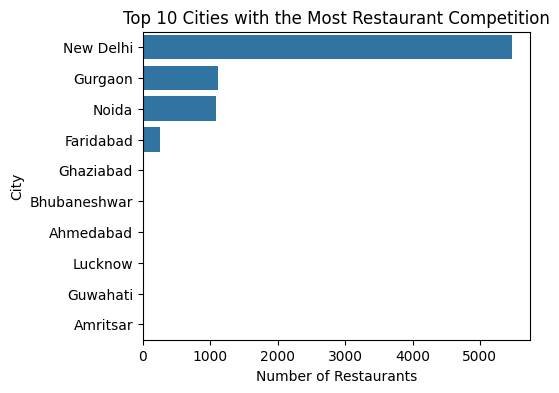

In [ ]:
top_cities = df['City'].value_counts().head(10)
plt.figure(figsize=(5,4))
sns.barplot(x=top_cities.values,
            y=top_cities.index)
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.title('Top 10 Cities with the Most Restaurant Competition')
plt.show()

### **Observation**

* **New Delhi, Gurgaon, and Noida** dominate the dataset with the **highest number of restaurants**.
* This suggests intense competition and a highly developed food ecosystem in these cities.

## **2. Pie Chart**
### **Which price range is most common?**

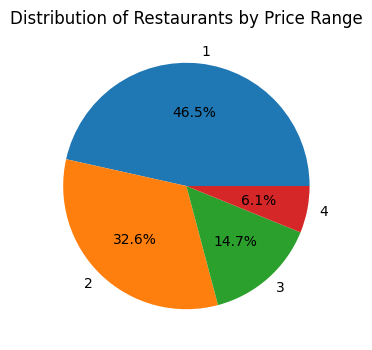

In [ ]:
price_counts = df['Price range'].value_counts()
plt.figure(figsize=(4,4))
plt.pie(price_counts,
        labels=price_counts.index,
        autopct='%1.1f%%')
plt.title('Distribution of Restaurants by Price Range')
plt.show()

### **Observation**
* Most restaurants belong to lower and mid-price segments, indicating strong customer demand for affordable dining options.

## **3. Scatter Plot**
### **Relationship between Ratings and Votes**

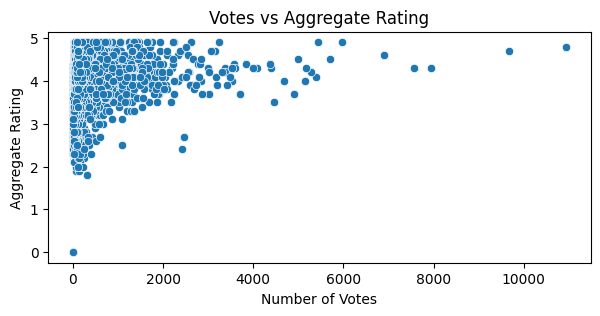

In [ ]:
plt.figure(figsize=(7,3))
sns.scatterplot(
    x='Votes',
    y='Aggregate rating',
    data=df
)
plt.title('Votes vs Aggregate Rating')
plt.xlabel('Number of Votes')
plt.ylabel('Aggregate Rating')
plt.show()

### **Observation**
* Restaurants with higher ratings tend to accumulate more votes, indicating a positive relationship between quality and customer engagement.

## **4. Line Chart**
### **Average Rating by Cuisine Type**

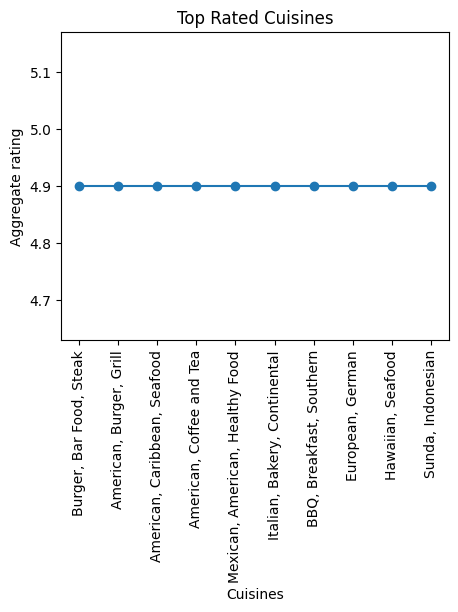

In [ ]:
top_cuisines_rating = (
    df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(5,4))
plt.plot(top_cuisine_rating.index,
         top_cuisine_rating.values,
         marker='o')
plt.xticks(rotation=90)
plt.title('Top Rated Cuisines')
plt.xlabel('Cuisines')
plt.ylabel('Aggregate rating')
plt.show()

### **Observation**
* Certain cuisines consistently receive higher ratings, suggesting stronger customer satisfaction and demand.

## **5. Heat Map**
### **What Drives Ratings?**

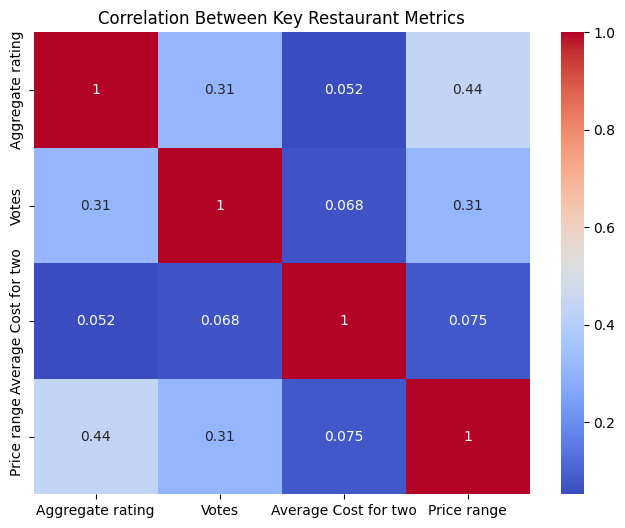

In [ ]:
plt.figure(figsize=(8,6))
corr = df[['Aggregate rating',
           'Votes',
           'Average Cost for two',
           'Price range']].corr()
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Between Key Restaurant Metrics')
plt.show()

### **Observation**
* Ratings often show stronger relationships with customer votes than with pricing, indicating that popularity and customer satisfaction are closely connected.

## **6. Histogram**
### **How Are Restaurant Ratings Distributed?**

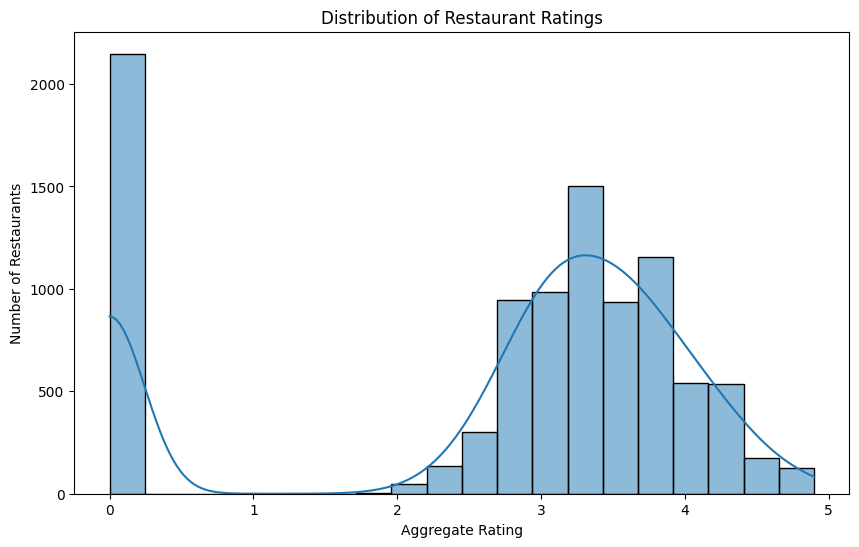

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Aggregate rating'],
             bins=20,
             kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.show()

### **Observation**
* Most restaurants are concentrated in the rating range of approximately 2.5 to 4.0.
* Very few restaurants have extremely low ratings or near-perfect ratings.
* This indicates that the majority of restaurants provide an average to good customer experience.

## **7. Box Plot**
### **How do restaurant ratings vary across different price ranges?**

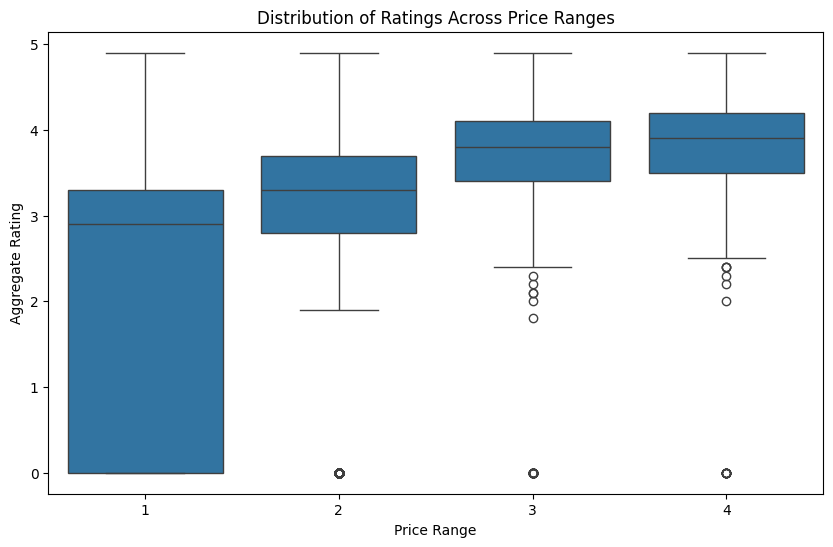

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Price range',
    y='Aggregate rating',
    data=df
)
plt.title('Distribution of Ratings Across Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Aggregate Rating')
plt.show()

### **Observation**
* Restaurants in higher price ranges generally tend to have higher median ratings.
* However, variability exists across all price categories, indicating that higher prices do not always guarantee better customer satisfaction.

## **Step 5 - Insights Report**

### The restaurant market is highly concentrated in New Delhi, indicating intense competition and making market entry more challenging for new businesses.

### **1. Market Competition is Concentrated in Major Cities**
* Based on the **Top 10 Cities by Restaurant Count** bar chart, **cities such as New Delhi, Gurgaon, and Noida** contain the highest number of restaurants.
* This indicates **intense market competition** in these locations.
* **New restaurant businesses** entering these cities **should focus on** differentiation through **unique cuisines, customer experience, or specialized services**.

### **2. Affordable and Mid-Range Restaurants Dominate the Market**

* The **pie chart showing** restaurant distribution by price range reveals that most restaurants operate in **lower and mid-price segments**.
* This suggests that **customers prefer affordable dining options**, making these segments attractive for business expansion and investment.

### **3. Online Delivery Improves Customer Engagement**

* The analysis comparing online delivery availability and average customer votes shows that **restaurants offering online delivery** generally **receive higher customer engagement**.
* This suggests that **adopting delivery services** can **improve restaurant visibility** and attract more customer interactions.

### **4. Customer Satisfaction Drives Restaurant Popularity**

* The **scatter plot** between votes and aggregate ratings **indicates a positive relationship between customer ratings and customer engagement**.
* Restaurants with **better ratings** tend to **receive more votes**, highlighting the **importance of service quality, food quality, and customer satisfaction in building popularity**.

### **5. Premium Pricing Alone Does Not Guarantee Success**

* The **box plot** and correlation analysis show that although higher-priced restaurants often receive good ratings, many lower-priced restaurants also achieve strong customer satisfaction.
* This indicates that customers value overall dining experience more than price alone. Restaurants should focus on delivering value rather than relying solely on premium pricing strategies.


### **Short Note**
* The most surprising finding was that online delivery appeared to be associated with higher customer ratings.
* Initially, I expected food quality alone to drive ratings, but the analysis showed that convenience also has a significant impact on customer satisfaction.
 * This demonstrates how customer experience extends beyond the food itself.
* It highlights the importance of digital services in the restaurant industry.